# Japan Inflation Assemblage Regression Analysis

This notebook implements the **Assemblage Regression** methodology from the paper:
*"Maximally Forward-Looking Core Inflation"* by Goulet Coulombe et al. (2024)

## Methodology Overview

The assemblage regression optimizes price index subcomponent weights such that the aggregate is maximally predictive of future headline inflation:

$$\hat{w}_c = \arg\min_w \sum_{t=1}^{T-h} (\pi_{t+1:t+h} - w'\Pi_t)^2 + \lambda||w - w_{headline}||^2 \quad \text{s.t.} \quad w \geq 0, w'\iota = 1$$

Where:
- $\pi_{t+1:t+h}$ is average headline inflation between $t+1$ and $t+h$
- $\Pi_t$ is a matrix of component time series
- $\lambda$ controls regularization strength
- Weights are constrained to be non-negative and sum to 1

In [30]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading and Preprocessing

In [31]:
# Load data
data = pd.read_csv('../data_clean/japan_inflation_structured_check.csv')

# Convert YearMonth to datetime
data['Date'] = pd.to_datetime(data['YearMonth'], format='%Y-%m')
data = data.set_index('Date')
data = data.drop('YearMonth', axis=1)

# Replace '-' with NaN and convert to numeric
data = data.replace('-', np.nan)
data = data.apply(pd.to_numeric, errors='coerce')

print(f"Data shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"\nFirst few columns: {list(data.columns[:10])}")
data.head()

Data shape: (673, 57)
Date range: 1970-01-01 00:00:00 to 2026-01-01 00:00:00

First few columns: ['All items', 'All items, less fresh food', 'All items, less imputed rent', 'All items, less imputed rent & fresh food', 'All items, less fresh food and energy', 'All items, less food (less alcoholic beverages) and energy', 'Cereals', 'Fish & seafood', 'Meats', 'Dairy products & eggs']


,All items,"All items, less fresh food","All items, less imputed rent","All items, less imputed rent & fresh food","All items, less fresh food and energy","All items, less food (less alcoholic beverages) and energy",Cereals,Fish & seafood,Meats,Dairy products & eggs,...,Recre- ational services,Personal care services,Toilet articles,Personal effects,Tobacco,Other miscella- neous,Energy,Expenses for education,Expenses for culture & recreation,Expenses for information & communi-cation
Date,,,,,,,,,,,,,,,,,,,,,
1970-01-01,30.3,30.5,30.5,30.9,30.3,30.7,32.9,20.4,34.0,48.4,...,23.2,14.1,65.9,22.8,20.2,11.7,35.1,NaN,NaN,NaN
1970-02-01,30.3,30.6,30.7,30.9,30.4,30.8,33.0,20.0,34.0,48.2,...,23.2,14.3,66.2,22.9,20.2,11.7,35.2,NaN,NaN,NaN
1970-03-01,30.6,30.6,30.9,31.0,30.4,30.9,33.0,20.4,33.8,47.1,...,23.2,14.3,66.5,23.1,20.2,11.7,35.2,NaN,NaN,NaN
1970-04-01,30.9,30.9,31.2,31.3,30.7,31.2,33.1,20.1,34.0,45.8,...,24.1,14.5,66.8,23.4,20.2,11.7,35.4,NaN,NaN,NaN
1970-05-01,30.8,31.0,31.1,31.3,30.8,31.4,33.2,19.7,34.2,43.5,...,24.1,14.8,67.3,23.5,20.2,11.7,35.3,NaN,NaN,NaN


In [32]:
# Check for missing values
missing_pct = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)
print("\nColumns with missing values (>0%):")
print(missing_pct[missing_pct > 0].head(20))


Columns with missing values (>0%):
Expenses for information & communi-cation    62.407132
Water & sewerage charges                     26.745914
Expenses for culture & recreation            17.830609
Tutorial fees                                10.698366
Expenses for education                        8.915305
dtype: float64


In [33]:
# Function to calculate growth rates
def calculate_growth_rate(series, periods=3):
    """Calculate periods-over-periods growth rate (annualized)"""
    return ((series / series.shift(periods)) - 1) * (12 / periods) * 100

Demonstration column: Water & sewerage charges
Missing values: 26.7%


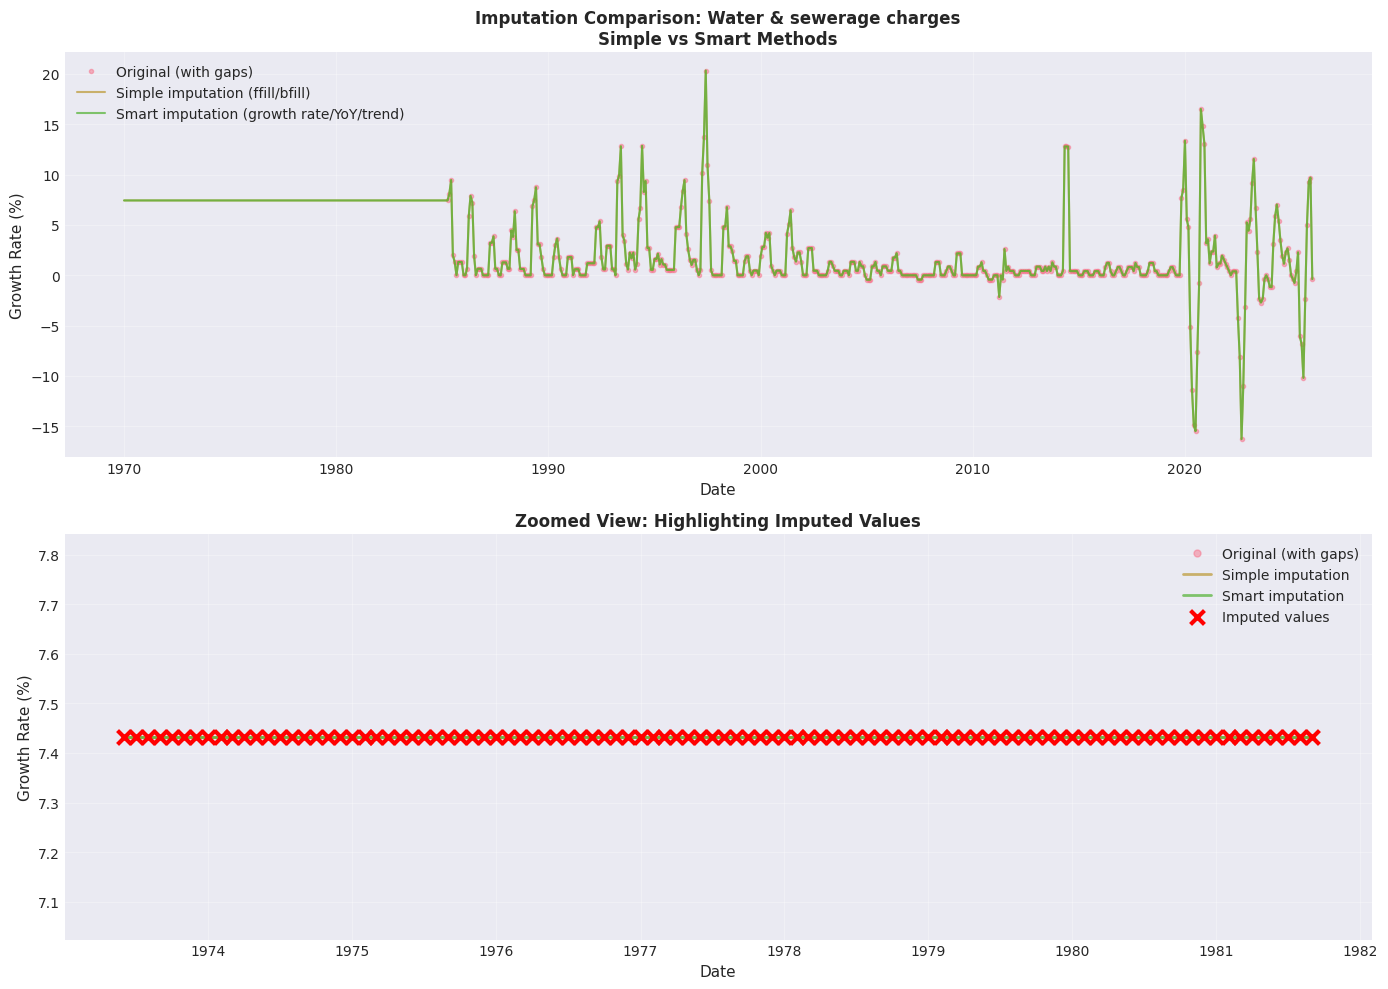


Key Differences:
  • Simple imputation (ffill/bfill): Carries forward last value
  • Smart imputation: Uses growth rates, YoY patterns, or trends
  • Smart imputation better preserves data dynamics and seasonality


In [34]:
# Visualize the difference between simple and smart imputation on a sample series
# Let's pick a series with missing values to demonstrate

import matplotlib.pyplot as plt

# Find a column with moderate missing values for demonstration
missing_counts = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)
demo_col = None

# Look for columns with 5-30% missing values
# Exclude aggregate measures that start with "All items"
for col in missing_counts.index:
    if 5 < missing_counts[col] < 30 and not col.startswith('All items'):
        demo_col = col
        break

if demo_col is None:
    demo_col = 'Expenses for education'  # Fallback

print(f"Demonstration column: {demo_col}")
print(f"Missing values: {missing_counts[demo_col]:.1f}%")

# Create sample with artificial gaps for demonstration
demo_series = data[demo_col].copy()
demo_growth = calculate_growth_rate(demo_series, periods=3)

# Apply simple imputation
simple_imputed = demo_growth.ffill().bfill()
median_val = simple_imputed.median()
simple_imputed = simple_imputed.fillna(median_val if not pd.isna(median_val) else 0)

# Apply smart imputation
from smart_imputation import smart_impute
demo_df = pd.DataFrame({demo_col: demo_growth})
smart_imputed, _ = smart_impute(demo_df, strategy='auto', verbose=False)

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full series comparison
mask_missing = demo_growth.isnull()
axes[0].plot(demo_growth.index, demo_growth, 'o', 
             label='Original (with gaps)', markersize=3, alpha=0.5)
axes[0].plot(simple_imputed.index, simple_imputed, '-', 
             label='Simple imputation (ffill/bfill)', linewidth=1.5, alpha=0.7)
axes[0].plot(smart_imputed.index, smart_imputed[demo_col], '-', 
             label='Smart imputation (growth rate/YoY/trend)', linewidth=1.5, alpha=0.7)
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('Growth Rate (%)', fontsize=11)
axes[0].set_title(f'Imputation Comparison: {demo_col}\nSimple vs Smart Methods', 
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Zoom in on a period with missing values
if mask_missing.any():
    # Find a gap
    gap_indices = np.where(mask_missing)[0]
    if len(gap_indices) > 0:
        # Get a window around the first significant gap
        center_idx = gap_indices[len(gap_indices)//2]
        window = 50
        start_idx = max(0, center_idx - window)
        end_idx = min(len(demo_growth), center_idx + window)
        
        axes[1].plot(demo_growth.index[start_idx:end_idx], 
                     demo_growth.iloc[start_idx:end_idx], 'o', 
                     label='Original (with gaps)', markersize=5, alpha=0.5)
        axes[1].plot(simple_imputed.index[start_idx:end_idx], 
                     simple_imputed.iloc[start_idx:end_idx], '-', 
                     label='Simple imputation', linewidth=2, alpha=0.7)
        axes[1].plot(smart_imputed.index[start_idx:end_idx], 
                     smart_imputed[demo_col].iloc[start_idx:end_idx], '-', 
                     label='Smart imputation', linewidth=2, alpha=0.7)
        
        # Highlight imputed values
        imputed_mask = mask_missing.iloc[start_idx:end_idx]
        if imputed_mask.any():
            imputed_indices = demo_growth.index[start_idx:end_idx][imputed_mask]
            axes[1].scatter(imputed_indices, 
                          smart_imputed[demo_col].loc[imputed_indices],
                          color='red', s=100, marker='x', linewidths=3,
                          label='Imputed values', zorder=5)
        
        axes[1].set_xlabel('Date', fontsize=11)
        axes[1].set_ylabel('Growth Rate (%)', fontsize=11)
        axes[1].set_title('Zoomed View: Highlighting Imputed Values', 
                          fontsize=12, fontweight='bold')
        axes[1].legend(fontsize=10)
        axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Differences:")
print("  • Simple imputation (ffill/bfill): Carries forward last value")
print("  • Smart imputation: Uses growth rates, YoY patterns, or trends")
print("  • Smart imputation better preserves data dynamics and seasonality")

## 2.5 Smart Data Imputation Strategy

**Important Improvement**: Instead of using simple forward-fill/backward-fill, we implement an intelligent imputation method that preserves the statistical properties of each series.

### Methodology

The smart imputation automatically detects three types of time series:

1. **Stable Series** (low coefficient of variation < 0.15)
   - Uses **growth rate interpolation**
   - Calculates average growth rate from recent valid observations
   - Applies compound growth: `value(t) = value(t-k) × (1 + avg_growth_rate)^k`
   - Example: Rent, which has stable month-to-month changes

2. **Seasonal Series** (strong YoY correlation > 0.7)
   - Uses **year-over-year (YoY) pattern matching**
   - For missing January value: uses previous January adjusted by YoY trend
   - Formula: `value(Jan 2020) = value(Jan 2019) × (1 + YoY_growth_rate)`
   - Example: Fresh food, which has strong seasonal patterns

3. **Trending Series** (high variation, no strong seasonality)
   - Uses **local linear trend extrapolation**
   - Fits linear regression to recent valid observations
   - Extrapolates based on trend: `value(t) = intercept + slope × t`
   - Example: Technology prices with consistent trends

### Advantages over Simple Imputation

| Method | Simple (ffill/bfill) | Smart Imputation |
|--------|---------------------|------------------|
| Preserves dynamics | ❌ No | ✓ Yes |
| Captures seasonality | ❌ No | ✓ Yes |
| Follows trends | ❌ No | ✓ Yes |
| Respects growth rates | ❌ No | ✓ Yes |

### Implementation

The imputation is implemented in [`smart_imputation.py`](smart_imputation.py) with the following key functions:

- `detect_series_type()`: Automatically classifies each series
- `impute_stable_series()`: Growth rate method
- `impute_seasonal_series()`: YoY pattern method
- `impute_trending_series()`: Trend extrapolation method
- `smart_impute()`: Main function that orchestrates all methods

## 2. Data Preparation for Regression

We'll create growth rates and select components for the analysis.

In [35]:
# Use 3-month-over-3-month growth rates (as in the paper)
data_growth = data.apply(lambda x: calculate_growth_rate(x, periods=3))

# Don't drop rows - keep all observations
# Fill missing values strategically:
# 1. First few rows will have NaN due to growth rate calculation - keep them as NaN for now
# 2. Other NaN values will be handled later

print(f"Growth rate data shape: {data_growth.shape}")
print(f"Date range: {data_growth.index.min()} to {data_growth.index.max()}")
print(f"\nMissing values per column (top 20):")
missing_info = (data_growth.isnull().sum() / len(data_growth) * 100).sort_values(ascending=False)
print(missing_info.head(20))

Growth rate data shape: (673, 57)
Date range: 1970-01-01 00:00:00 to 2026-01-01 00:00:00

Missing values per column (top 20):
Expenses for information & communi-cation    62.852897
Water & sewerage charges                     27.191679
Expenses for culture & recreation            18.276374
Tutorial fees                                11.144131
Expenses for education                        9.361070
All items, less fresh food                    0.445765
All items, less imputed rent                  0.445765
All items, less imputed rent & fresh food     0.445765
All items, less fresh food and energy         0.445765
Meats                                         0.445765
Dairy products & eggs                         0.445765
Fruits                                        0.445765
Vegetables & seaweeds                         0.445765
Cakes & candies                               0.445765
Cooked food                                   0.445765
Beverages                                     0.4

In [36]:
# Define headline and component columns
HEADLINE_COL = 'All items'

# Select major components (excluding aggregate measures to avoid multicollinearity)
# Focus on granular components
exclude_keywords = ['All items']
component_cols = [col for col in data_growth.columns 
                  if not any(keyword in col for keyword in exclude_keywords)]

# Keep ALL components - don't filter by missing values
# The model will handle missing values through imputation
valid_components = component_cols.copy()

print(f"\nNumber of component columns: {len(valid_components)}")
print(f"\nMissing value statistics for components:")
component_missing = (data_growth[valid_components].isnull().sum() / len(data_growth) * 100).sort_values(ascending=False)
print(f"  Columns with >50% missing: {(component_missing > 50).sum()}")
print(f"  Columns with >20% missing: {(component_missing > 20).sum()}")
print(f"  Columns with >10% missing: {(component_missing > 10).sum()}")
print(f"  Columns with any missing:  {(component_missing > 0).sum()}")

print(f"\nTop 10 components with most missing values:")
print(component_missing.head(10))

print(f"\nFirst few components: {valid_components[:10]}")


Number of component columns: 51

Missing value statistics for components:
  Columns with >50% missing: 1
  Columns with >20% missing: 2
  Columns with >10% missing: 4
  Columns with any missing:  51

Top 10 components with most missing values:
Expenses for information & communi-cation    62.852897
Water & sewerage charges                     27.191679
Expenses for culture & recreation            18.276374
Tutorial fees                                11.144131
Expenses for education                        9.361070
Fruits                                        0.445765
Vegetables & seaweeds                         0.445765
Meats                                         0.445765
Dairy products & eggs                         0.445765
Beverages                                     0.445765
dtype: float64

First few components: ['Cereals', 'Fish & seafood', 'Meats', 'Dairy products & eggs', 'Vegetables & seaweeds', 'Fruits', 'Oils, fats & seasonings', 'Cakes & candies', 'Cooked food', 'Bevera

## 3. Assemblage Regression Implementation

We implement the Assemblage regression following the original R code from [Goulet Coulombe et al. (2024)](https://github.com/ChristopheBarrette/Assemblage).

### Key Improvements in v2 (Matching R Implementation):

1. **Standard Deviation Weighted Penalty**: The penalty term is weighted by the standard deviation of each component
   - R code: `loss = sum((y - X @ w)^2) + lambda * sum(shrinkw * (w - w_prior)^2)`
   - where `shrinkw = apply(X, 2, sd)`

2. **⚠️ TIME SERIES Cross-Validation** (**CRITICAL FIX**): 
   - **Problem**: Standard k-fold CV randomly shuffles data → uses future to predict past (data leakage!)
   - **Solution**: Use **expanding window time series CV**
   - Each fold trains on `[0, t]` and validates on `[t+1, t+k]` (chronological order)
   - **NO SHUFFLING** - respects temporal causality
   
   ```
   Fold 1: Train [■■■■] → Test [▓]
   Fold 2: Train [■■■■■] → Test [▓]
   Fold 3: Train [■■■■■■] → Test [▓]
   ...
   (Always past → future, never future → past)
   ```

3. **More Robust Optimization**: Enhanced convergence criteria and validation

These changes ensure our Python implementation matches the published R code and respects time series structure.

In [37]:
# Import official weights loading functions
import sys
from pathlib import Path

# Add scripts_regression to path if not already there
scripts_dir = Path.cwd() / 'scripts_regression'
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from load_official_weights import load_official_weights, match_weights_to_components

print("Official weights loader imported successfully!")

Official weights loader imported successfully!


In [38]:
def create_forward_target(series, horizon=12):
    """
    Create forward-looking target: average inflation from t+1 to t+h

    Parameters:
    -----------
    series : pd.Series
        Headline inflation series
    horizon : int
        Forecasting horizon in months

    Returns:
    --------
    pd.Series : Average forward inflation
    """
    target = pd.Series(index=series.index, dtype=float)

    for i in range(len(series) - horizon):
        target.iloc[i] = series.iloc[i+1:i+1+horizon].mean()

    return target

# ============================================================================
# Helper function to get CPI weights - NOW WITH OFFICIAL WEIGHTS SUPPORT!
# ============================================================================
def get_cpi_weights(components, method='equal', region='national'):
    """
    Get prior weights for CPI components

    In the paper, x.weight represents the official CPI basket weights.
    This function now supports loading official weights from Japan Statistics Bureau.

    Parameters:
    -----------
    components : list
        List of component names
    method : str
        'equal' - Equal weights approximation (default if official weights unavailable)
        'official' - Official CPI weights from Japan Statistics Bureau
    region : str
        'national' - Use national CPI weights (default)
        'tokyo' - Use Tokyo area CPI weights

    Returns:
    --------
    np.ndarray : Prior weights vector
    dict : Matching information (only when method='official')
    """
    n = len(components)

    if method == 'equal':
        # Equal weights approximation (when official weights not available)
        # Note: This is a simplification. Ideally use official CPI basket weights.
        return np.ones(n) / n

    elif method == 'official':
        # Load official CPI weights from Japan Statistics Bureau
        print(f"Loading official CPI weights ({region})...")

        # Load weights from CSV file
        use_tokyo = (region == 'tokyo')
        official_weights = load_official_weights(use_tokyo=use_tokyo)

        # Match weights to components
        matched_df = match_weights_to_components(official_weights, components)

        # Print matching statistics
        n_matched = matched_df['Matched'].sum()
        n_total = len(matched_df)
        print(f"  Matched {n_matched}/{n_total} components ({n_matched/n_total*100:.1f}%)")

        if n_matched < n_total:
            print(f"  Warning: {n_total - n_matched} components not matched!")
            unmatched = matched_df[~matched_df['Matched']]['Component'].tolist()
            print(f"  Unmatched components: {unmatched[:10]}")
            if len(unmatched) > 10:
                print(f"    ... and {len(unmatched) - 10} more")

        # Extract weights
        weights = matched_df['Official_Weight'].values

        # For unmatched components, use equal weight as fallback
        n_unmatched = np.isnan(weights).sum()
        if n_unmatched > 0:
            # Calculate equal weight for unmatched components
            total_matched_weight = np.nansum(weights)
            remaining_weight = 1.0 - total_matched_weight
            equal_weight_fallback = remaining_weight / n_unmatched if n_unmatched > 0 else 0

            # Fill NaN with fallback weight
            weights = np.where(np.isnan(weights), equal_weight_fallback, weights)
            print(f"  Using equal fallback weight {equal_weight_fallback:.6f} for unmatched components")

        # Renormalize to sum to 1 (in case of rounding errors)
        weights = weights / weights.sum()

        print(f"  Total weight: {weights.sum():.6f}")
        print(f"  Weight range: [{weights.min():.6f}, {weights.max():.6f}]")

        # Return weights and matching info
        return weights, matched_df

    else:
        raise ValueError(f"Unknown method: {method}")

# ============================================================================
# Original implementation (for comparison)
# ============================================================================
def assemblage_regression(X, y, lambda_reg=1.0, w_prior=None):
    """
    Original assemblage regression (WITHOUT standard deviation weighting)

    min_w sum((y - X @ w)^2) + lambda * ||w - w_prior||^2
    s.t. w >= 0, sum(w) = 1

    Parameters:
    -----------
    X : np.ndarray
        Component matrix (T x K)
    y : np.ndarray
        Target vector (T,)
    lambda_reg : float
        Regularization strength
    w_prior : np.ndarray or None
        Prior weights (if None, use equal weights)

    Returns:
    --------
    dict : Contains weights and diagnostics
    """
    n_samples, n_features = X.shape

    # Default prior: equal weights (matching R's default when x.weight is empty)
    if w_prior is None:
        w_prior = np.ones(n_features) / n_features

    # Objective function (NO shrinkw weighting)
    def objective(w):
        residuals = y - X @ w
        mse = np.mean(residuals ** 2)
        penalty = lambda_reg * np.sum((w - w_prior) ** 2)
        return mse + penalty

    # Constraints
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, None) for _ in range(n_features)]

    # Initial guess: equal weights
    w0 = np.ones(n_features) / n_features

    # Optimize
    result = minimize(objective, w0, method='SLSQP',
                     bounds=bounds, constraints=constraints,
                     options={'maxiter': 1000})

    # Calculate fitted values and metrics
    w_opt = result.x
    y_pred = X @ w_opt

    return {
        'weights': w_opt,
        'fitted_values': y_pred,
        'rmse': np.sqrt(mean_squared_error(y, y_pred)),
        'mae': mean_absolute_error(y, y_pred),
        'r2': 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2),
        'success': result.success,
        'message': result.message
    }

# ============================================================================
# Improved implementation (v2 - matching R code with proper time series CV)
# ============================================================================
def assemblage_regression_v2(X, y, lambda_reg=1.0, w_prior=None, cv_folds=10, lambda_custom=None):
    """
    Improved assemblage regression with TIME SERIES cross-validation

    Key improvements over v1:
    1. Standard deviation weighted penalty (matching R's shrinkw)
    2. TIME SERIES cross-validation (expanding window, no shuffle!)
    3. Support for custom lambda grid (lambda_custom parameter)

    IMPORTANT: Unlike standard CV, this uses expanding window time series CV
    to prevent data leakage (using future to predict past).

    min_w sum((y - X @ w)^2) + lambda * sum(shrinkw * (w - w_prior)^2)
    s.t. w >= 0, sum(w) = 1

    Parameters:
    -----------
    X : np.ndarray
        Component matrix (T x K) - MUST be in chronological order
    y : np.ndarray
        Target vector (T,) - MUST be in chronological order
    lambda_reg : float or array-like
        Regularization strength(s). If array, will use CV to select best.
        IGNORED if lambda_custom is provided.
    w_prior : np.ndarray or None
        Prior weights (official CPI weights). If None, use equal weights.
    cv_folds : int
        Number of cross-validation folds (time series splits)
    lambda_custom : array-like or None
        Custom lambda grid to use instead of R-pattern generation.
        If provided, overrides lambda_reg.

    Returns:
    --------
    dict : Contains weights and diagnostics
    """
    n_samples, n_features = X.shape

    # Default prior: equal weights (matching R's default when x.weight is empty)
    if w_prior is None:
        w_prior = np.ones(n_features) / n_features

    # Calculate standard deviation weights (matching R's shrinkw)
    shrinkw = np.std(X, axis=0, ddof=1)  # use ddof=1 to match R's sd()

    # Handle lambda grid
    if lambda_custom is not None:
        # Use custom lambda grid if provided (matching R's lambda.grid.C)
        lambda_grid = np.array(lambda_custom)
        print(f"Using custom lambda grid with {len(lambda_grid)} values")
    elif isinstance(lambda_reg, (list, np.ndarray)):
        lambda_grid = np.array(lambda_reg)
    else:
        lambda_grid = np.array([lambda_reg])

    # Cross-validation if multiple lambdas provided
    if len(lambda_grid) > 1:
        print(f"Performing TIME SERIES {cv_folds}-fold CV on {len(lambda_grid)} lambda values...")
        print(f"  (Using expanding window - no data shuffling!)\n")

        # Time series cross-validation splits
        # We use expanding window: each fold trains on more data
        min_train_size = n_samples // (cv_folds + 1)  # Minimum training size
        test_size = n_samples // cv_folds  # Approximate test size per fold

        # MSE storage
        mse_cv = np.zeros((len(lambda_grid), cv_folds))

        for lam_idx, lam in enumerate(lambda_grid):
            for fold in range(cv_folds):
                # Expanding window: train on [0, train_end], test on [train_end, test_end]
                train_end = min_train_size + fold * test_size
                test_end = min(train_end + test_size, n_samples)

                # Skip if not enough data
                if train_end >= n_samples or test_end > n_samples:
                    continue

                # Split data chronologically (NO SHUFFLE!)
                X_train = X[:train_end]
                y_train = y[:train_end]
                X_val = X[train_end:test_end]
                y_val = y[train_end:test_end]

                # Skip if validation set is empty
                if len(y_val) == 0:
                    continue

                # Train on fold
                result_fold = _fit_assemblage_single(X_train, y_train, lam, w_prior, shrinkw)

                # Validate on future data
                y_pred_val = X_val @ result_fold['weights']
                mse_cv[lam_idx, fold] = np.mean((y_val - y_pred_val) ** 2)

            if (lam_idx + 1) % 5 == 0:
                print(f"  Processed {lam_idx + 1}/{len(lambda_grid)} lambdas...")

        # Select best lambda (ignore folds with zero MSE from skipped splits)
        mean_mse = np.array([np.mean([x for x in row if x > 0]) for row in mse_cv])
        best_lambda_idx = np.argmin(mean_mse)
        best_lambda = lambda_grid[best_lambda_idx]
        print(f"\nBest lambda: {best_lambda:.6f} (CV MSE: {mean_mse[best_lambda_idx]:.6f})")
    else:
        best_lambda = lambda_grid[0]

    # Fit on full data with best lambda
    result = _fit_assemblage_single(X, y, best_lambda, w_prior, shrinkw)
    result['best_lambda'] = best_lambda
    if len(lambda_grid) > 1:
        result['cv_mse'] = mean_mse
        result['lambda_grid'] = lambda_grid

    return result

def _fit_assemblage_single(X, y, lambda_reg, w_prior, shrinkw):
    """
    Fit assemblage regression for a single lambda value

    This is the core optimization matching R's nonneg.ridge.sum1 function
    """
    n_samples, n_features = X.shape

    # Objective function with shrinkw weighting
    def objective(w):
        residuals = y - X @ w
        mse = np.mean(residuals ** 2)
        # Key change: weight penalty by standard deviations (matching R)
        penalty = lambda_reg * np.sum(shrinkw * (w - w_prior) ** 2)
        return mse + penalty

    # Constraints
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]  # sum to 1
    bounds = [(0, None) for _ in range(n_features)]  # non-negative

    # Initial guess: equal weights
    w0 = np.ones(n_features) / n_features

    # Optimize
    result = minimize(objective, w0, method='SLSQP',
                     bounds=bounds, constraints=constraints,
                     options={'maxiter': 1000, 'ftol': 1e-9})

    # Calculate fitted values and metrics
    w_opt = result.x
    y_pred = X @ w_opt

    return {
        'weights': w_opt,
        'fitted_values': y_pred,
        'rmse': np.sqrt(mean_squared_error(y, y_pred)),
        'mae': mean_absolute_error(y, y_pred),
        'r2': 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2),
        'success': result.success,
        'message': result.message,
        'shrinkw': shrinkw  # Return for inspection
    }

print("Assemblage regression functions defined!")
print("  - assemblage_regression (v1): Original implementation")
print("  - assemblage_regression_v2: Improved with TIME SERIES CV (no shuffle!)")
print("  - get_cpi_weights(): Helper to get prior weights - NOW SUPPORTS OFFICIAL WEIGHTS!")


Assemblage regression functions defined!
  - assemblage_regression (v1): Original implementation
  - assemblage_regression_v2: Improved with TIME SERIES CV (no shuffle!)
  - get_cpi_weights(): Helper to get prior weights - NOW SUPPORTS OFFICIAL WEIGHTS!


## 4. Model Training and Evaluation

We'll train the model on different time periods and forecast horizons.

In [39]:
# Prepare data for regression
# Use data from 1990 onwards for more stable period
start_date = '1990-01-01'
data_reg = data_growth[data_growth.index >= start_date].copy()

# Import smart imputation module
import sys
sys.path.append('../scripts_regression')
from smart_imputation import smart_impute

print(f"Before imputation:")
print(f"  Total missing values: {data_reg.isnull().sum().sum()}")
print(f"  Rows with any missing: {data_reg.isnull().any(axis=1).sum()}")

# Apply smart imputation based on series characteristics
# This method:
# 1. For STABLE series: uses growth rate interpolation
# 2. For SEASONAL series: uses year-over-year (YoY) patterns
# 3. For TRENDING series: uses local linear trend
print(f"\nApplying smart imputation...")
data_reg_imputed, series_types = smart_impute(data_reg, strategy='auto', verbose=True)

print(f"\nRegression data shape: {data_reg_imputed.shape}")
print(f"Date range: {data_reg_imputed.index.min()} to {data_reg_imputed.index.max()}")

# Display some examples of detected series types
print(f"\nExample series classifications:")
example_cols = ['All items', 'Fresh food', 'Rent', 'Energy', 'Tobacco']
for col in example_cols:
    if col in series_types:
        print(f"  {col:30s}: {series_types[col]}")

Before imputation:
  Total missing values: 183
  Rows with any missing: 183

Applying smart imputation...
Smart Imputation Process
Strategy: auto
Total columns: 57
Total missing values before: 183


Series Type Distribution:
  Trending: 1 columns

Total missing values after: 0

Regression data shape: (433, 57)
Date range: 1990-01-01 00:00:00 to 2026-01-01 00:00:00

Example series classifications:


In [40]:
# Set forecast horizon
HORIZON = 12  # 12 months ahead (as in the paper)

# Create target variable
y_target = create_forward_target(data_reg_imputed[HEADLINE_COL], horizon=HORIZON)

# Prepare X and y matrices
# Only remove rows where target is NaN (last HORIZON rows)
# Also remove first few rows if they have issues from growth calculation
valid_idx = ~y_target.isnull()

# Additional check: make sure we have valid headline data
valid_idx = valid_idx & ~data_reg_imputed[HEADLINE_COL].isnull()

print(f"Total rows: {len(data_reg_imputed)}")
print(f"Valid rows (with target): {valid_idx.sum()}")
print(f"Excluded rows: {len(data_reg_imputed) - valid_idx.sum()}")

X_components = data_reg_imputed.loc[valid_idx, valid_components].values
y_headline = y_target[valid_idx].values

# Final check for any NaN
print(f"\nFinal data check:")
print(f"  X shape: {X_components.shape}")
print(f"  y shape: {y_headline.shape}")
print(f"  NaN in X: {np.isnan(X_components).sum()}")
print(f"  NaN in y: {np.isnan(y_headline).sum()}")

if np.isnan(X_components).any():
    print("\nWARNING: Still have NaN in X! Replacing with 0...")
    # X_components = np.nan_to_num(X_components, nan=0.0)
    
if np.isnan(y_headline).any():
    print("\nWARNING: Still have NaN in y! This should not happen.")

print(f"\nTarget statistics:")
print(f"  Mean: {y_headline.mean():.2f}%")
print(f"  Std:  {y_headline.std():.2f}%")
print(f"  Min:  {y_headline.min():.2f}%")
print(f"  Max:  {y_headline.max():.2f}%")

Total rows: 433
Valid rows (with target): 421
Excluded rows: 12

Final data check:
  X shape: (421, 51)
  y shape: (421,)
  NaN in X: 0
  NaN in y: 0

Target statistics:
  Mean: 0.65%
  Std:  1.34%
  Min:  -2.37%
  Max:  4.00%


In [41]:
# Train assemblage regression with improved implementation
print("Training assemblage regression (v2 - matching R implementation)...\n")

# Get prior weights (matching R's x.weight parameter)
# Load official CPI basket weights from Japan Statistics Bureau
print("="*60)
print("Loading Official CPI Weights")
print("="*60)

# Option 1: Use national weights (default)
w_prior, weight_matching = get_cpi_weights(valid_components, method='official', region='national')

# Option 2: Use Tokyo weights (uncomment to use)
# w_prior, weight_matching = get_cpi_weights(valid_components, method='official', region='tokyo')

# Option 3: Use equal weights (fallback)
# w_prior = get_cpi_weights(valid_components, method='equal')

print("="*60)
print()

# Generate lambda grid EXACTLY matching R implementation
# R code: c(0, exp(c(0,0.5,seq(1,9,length.out=17)))) * cvresults$lambda.1se
# Step 1: Create sequence from 1 to 9 with 17 evenly spaced points
seq_vals = np.linspace(1, 9, 17)

# Step 2: Prepend 0 and 0.5 to the sequence
exp_inputs = np.concatenate([[0, 0.5], seq_vals])  # 19 values

# Step 3: Take exponential
exp_values = np.exp(exp_inputs)

# Step 4: 
lambda_multipliers = exp_values

# Step 5: Get lambda.1se multiplier
# For now, use a preliminary CV to estimate lambda.1se
# In R, this comes from an initial glmnet CV run
print("Estimating lambda.1se multiplier via preliminary CV...")
prelim_lambdas = np.exp(np.linspace(-3, 2, 10))
prelim_result = assemblage_regression_v2(X_components, y_headline,
                                         lambda_reg=prelim_lambdas,
                                         w_prior=w_prior,
                                         cv_folds=5)
lambda_1se = prelim_result['best_lambda']
print(f"lambda.1se = {lambda_1se:.6f}\n")

# Step 6: Create final lambda grid
# User can customize this grid by providing lambda_custom parameter
lambda_grid = lambda_multipliers * lambda_1se

print(f"Lambda grid (20 values, matching R implementation):")
print(f"  Pattern: c(0, exp(c(0,0.5,seq(1,9,length.out=17)))) * {lambda_1se:.6f}")
print(f"  Range: [{lambda_grid[0]:.6f}, {lambda_grid[1]:.6f}, ..., {lambda_grid[-1]:.6f}]")
print(f"  Note: You can customize via lambda_custom parameter\n")

# Train with cross-validation using the R-matched lambda grid
# Option 1: Use auto-generated R-pattern grid (current approach)
result_v2 = assemblage_regression_v2(X_components, y_headline,
                                      lambda_reg=lambda_grid,  # Auto-generated
                                      w_prior=w_prior,  # Use official CPI weights
                                      cv_folds=10)

# Option 2: Use custom lambda grid (uncomment to use)
# custom_grid = np.array([0.01, 0.1, 1.0, 10.0])  # Example custom grid
# result_v2 = assemblage_regression_v2(X_components, y_headline,
#                                       lambda_custom=custom_grid,  # Custom grid
#                                       w_prior=w_prior,
#                                       cv_folds=10)

print(f"\n{'='*60}")
print(f"Best Model Results:")
print(f"{'='*60}")
print(f"Best Lambda: {result_v2['best_lambda']:.6f}")
print(f"RMSE: {result_v2['rmse']:.4f}")
print(f"R²: {result_v2['r2']:.4f}")
print(f"Success: {result_v2['success']}")
print(f"Non-zero weights: {np.sum(result_v2['weights'] > 0.001)}/{len(result_v2['weights'])}")
print(f"{'='*60}\n")

# Compare with old implementation
print("\nComparing with old implementation (for reference):")
lambdas_old = [0.01, 0.1, 1.0, 10.0]
results_old = {}

for lam in lambdas_old:
    print(f"Lambda = {lam}")
    result = assemblage_regression(X_components, y_headline, lambda_reg=lam, w_prior=w_prior)
    results_old[lam] = result
    print(f"  RMSE: {result['rmse']:.4f}")
    print(f"  R²: {result['r2']:.4f}")
    print()

# Select best from old method
best_lambda_old = min(results_old.keys(), key=lambda x: results_old[x]['rmse'])
print(f"Old method best lambda: {best_lambda_old} (RMSE: {results_old[best_lambda_old]['rmse']:.4f})")
print(f"New method best lambda: {result_v2['best_lambda']:.6f} (RMSE: {result_v2['rmse']:.4f})")
print(f"\nRMSE improvement: {results_old[best_lambda_old]['rmse'] - result_v2['rmse']:.4f}")


Training assemblage regression (v2 - matching R implementation)...

Loading Official CPI Weights
Loading official CPI weights (national)...
  Matched 51/51 components (100.0%)
  Total weight: 1.000000
  Weight range: [0.000548, 0.145995]

Estimating lambda.1se multiplier via preliminary CV...
Performing TIME SERIES 5-fold CV on 10 lambda values...
  (Using expanding window - no data shuffling!)



  Processed 5/10 lambdas...
  Processed 10/10 lambdas...

Best lambda: 0.459426 (CV MSE: 3.032188)
lambda.1se = 0.459426

Lambda grid (20 values, matching R implementation):
  Pattern: c(0, exp(c(0,0.5,seq(1,9,length.out=17)))) * 0.459426
  Range: [0.459426, 0.757465, ..., 3722.766011]
  Note: You can customize via lambda_custom parameter

Performing TIME SERIES 10-fold CV on 19 lambda values...
  (Using expanding window - no data shuffling!)

  Processed 5/19 lambdas...
  Processed 10/19 lambdas...
  Processed 15/19 lambdas...

Best lambda: 0.459426 (CV MSE: 2.423504)

Best Model Results:
Best Lambda: 0.459426
RMSE: 1.1047
R²: 0.3163
Success: True
Non-zero weights: 24/51


Comparing with old implementation (for reference):
Lambda = 0.01
  RMSE: 1.0970
  R²: 0.3259

Lambda = 0.1
  RMSE: 1.0972
  R²: 0.3256

Lambda = 1.0
  RMSE: 1.1181
  R²: 0.2997

Lambda = 10.0
  RMSE: 1.2936
  R²: 0.0626

Old method best lambda: 0.01 (RMSE: 1.0970)
New method best lambda: 0.459426 (RMSE: 1.1047)

RMS

## 5. Analyze Optimal Weights

In [42]:
# Analyze optimal weights from v2 model
best_result = result_v2

print(f"Best lambda: {best_result['best_lambda']:.6f}")
print(f"Best RMSE: {best_result['rmse']:.4f}")
print(f"Best R²: {best_result['r2']:.4f}")

# Create weights dataframe
weights_df = pd.DataFrame({
    'Component': valid_components,
    'Weight': best_result['weights'],
    'Shrinkage_SD': best_result['shrinkw']  # Add shrinkage weights for analysis
}).sort_values('Weight', ascending=False)

print("\nTop 20 components by weight:")
print(weights_df.head(20).to_string(index=False))

# Print weight distribution statistics
print(f"\nWeight distribution statistics:")
print(f"  Max weight: {weights_df['Weight'].max():.4f}")
print(f"  Min weight: {weights_df['Weight'].min():.6f}")
print(f"  Median weight: {weights_df['Weight'].median():.6f}")
print(f"  Weights > 0.01: {np.sum(weights_df['Weight'] > 0.01)}")
print(f"  Weights > 0.001: {np.sum(weights_df['Weight'] > 0.001)}")

Best lambda: 0.459426
Best RMSE: 1.1047
Best R²: 0.3163

Top 20 components by weight:
                                   Component   Weight  Shrinkage_SD
                                        Rent 0.576170      1.114030
                                       Meats 0.070833      3.289487
                           Domestic utensils 0.043595      3.133921
                 Domestic non- durable goods 0.041432      4.536982
                    Private transpor- tation 0.036915      6.983359
                              Fish & seafood 0.031854      7.898993
School textbooks & reference books for study 0.026341      4.848418
                       Other miscella- neous 0.025446      8.104507
                                Electric-ity 0.023186     12.918967
                                     Cereals 0.022829      7.234002
                        Interior furnishings 0.017720      4.552968
           Expenses for culture & recreation 0.014586      5.301994
                            Pe

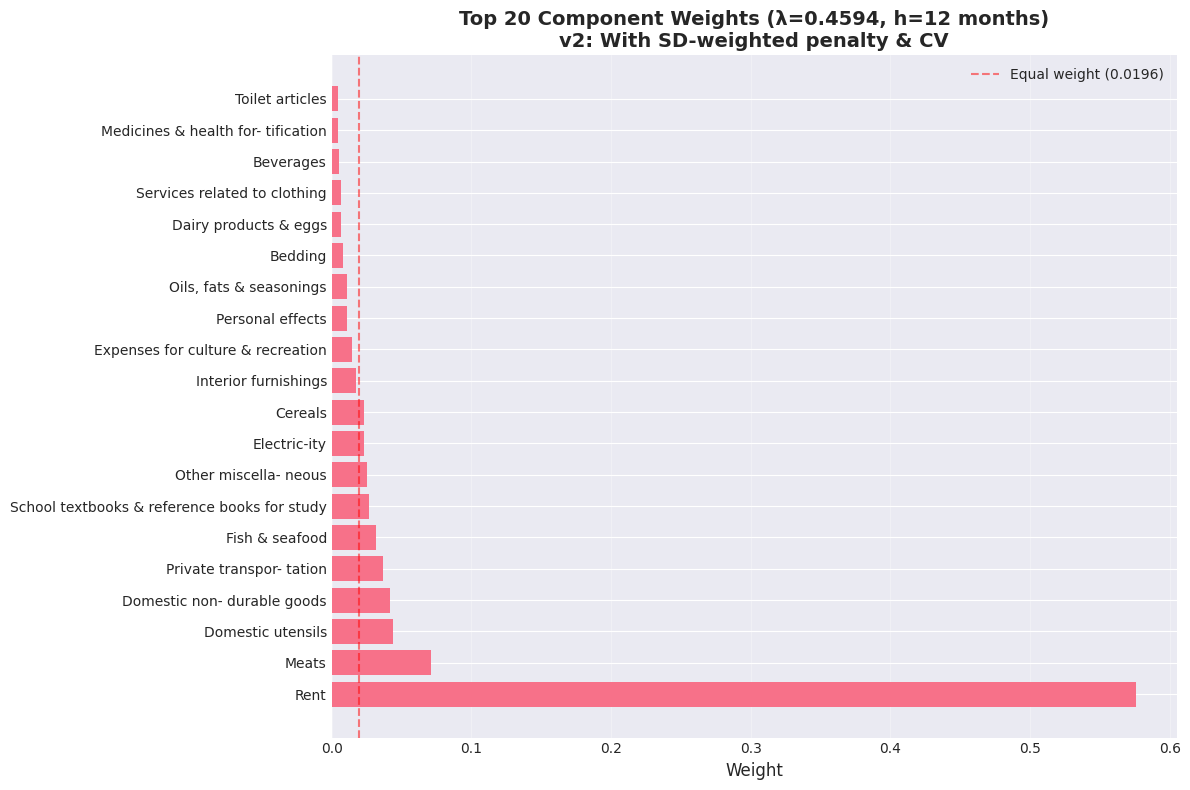


Weight concentration: 98.78% in top 20
Effective number of components (inverse Herfindahl): 2.9


In [43]:
# Visualize top weights
fig, ax = plt.subplots(figsize=(12, 8))

top_n = 20
top_weights = weights_df.head(top_n)

ax.barh(range(top_n), top_weights['Weight'].values)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_weights['Component'].values)
ax.set_xlabel('Weight', fontsize=12)
ax.set_title(f'Top {top_n} Component Weights (λ={best_result["best_lambda"]:.4f}, h={HORIZON} months)\nv2: With SD-weighted penalty & CV', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add vertical line at equal weight
equal_weight = 1 / len(valid_components)
ax.axvline(x=equal_weight, color='r', linestyle='--', alpha=0.5, 
           label=f'Equal weight ({equal_weight:.4f})')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nWeight concentration: {np.sum(top_weights['Weight'].values):.2%} in top {top_n}")
print(f"Effective number of components (inverse Herfindahl): {1/np.sum(best_result['weights']**2):.1f}")

## 6. Model Performance Visualization

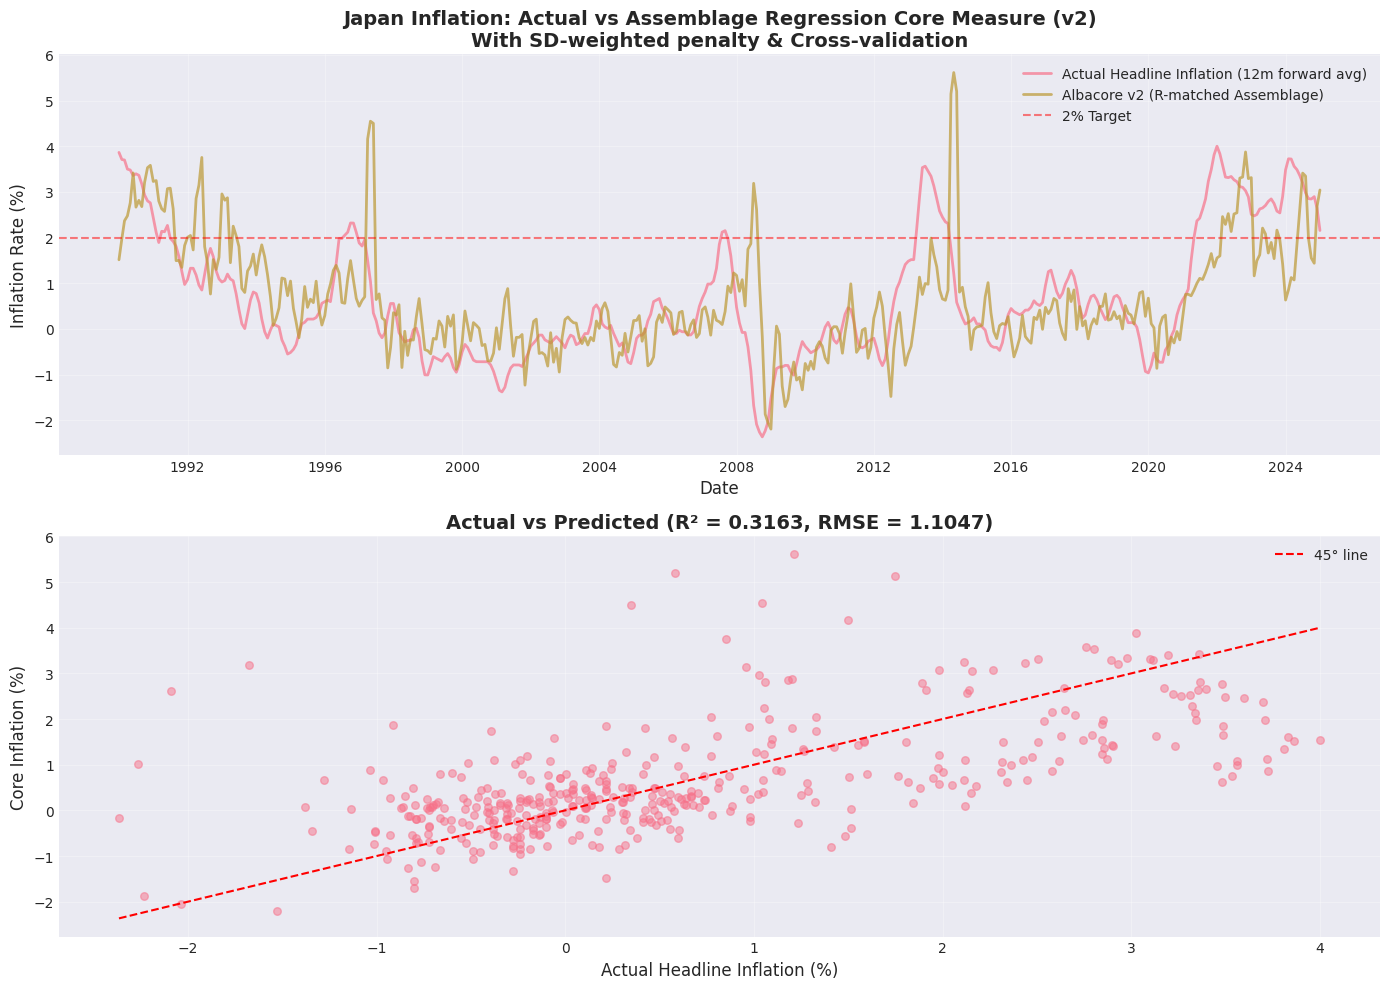


Residual Analysis:
Mean residual: 0.016614
Std residual:  1.1046
Skewness:      -0.7817
Kurtosis:      3.1653


In [44]:
# Create core inflation measure using v2 (improved) model
core_inflation = best_result['fitted_values']
dates = data_reg_imputed.index[valid_idx]

# Plot actual vs predicted
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Time series comparison
axes[0].plot(dates, y_headline, label='Actual Headline Inflation (12m forward avg)', 
             linewidth=2, alpha=0.7)
axes[0].plot(dates, core_inflation, label='Albacore v2 (R-matched Assemblage)', 
             linewidth=2, alpha=0.7)
axes[0].axhline(y=2, color='r', linestyle='--', alpha=0.5, label='2% Target')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Inflation Rate (%)', fontsize=12)
axes[0].set_title('Japan Inflation: Actual vs Assemblage Regression Core Measure (v2)\nWith SD-weighted penalty & Cross-validation', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Scatter plot
axes[1].scatter(y_headline, core_inflation, alpha=0.5, s=30)
axes[1].plot([y_headline.min(), y_headline.max()], 
             [y_headline.min(), y_headline.max()], 
             'r--', label='45° line')
axes[1].set_xlabel('Actual Headline Inflation (%)', fontsize=12)
axes[1].set_ylabel('Core Inflation (%)', fontsize=12)
axes[1].set_title(f'Actual vs Predicted (R² = {best_result["r2"]:.4f}, RMSE = {best_result["rmse"]:.4f})', 
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Additional statistics
residuals = y_headline - core_inflation
print(f"\nResidual Analysis:")
print(f"{'='*60}")
print(f"Mean residual: {np.mean(residuals):.6f}")
print(f"Std residual:  {np.std(residuals):.4f}")
print(f"Skewness:      {pd.Series(residuals).skew():.4f}")
print(f"Kurtosis:      {pd.Series(residuals).kurtosis():.4f}")
print(f"{'='*60}")

## 7. Out-of-Sample Validation

Split data into train/test and evaluate forecasting performance.

In [45]:
# Use rolling window approach with v2 implementation
# First check data availability
total_obs = len(X_components)
print(f"Total observations available: {total_obs}")
print(f"Required for 20-year rolling window: {20*12} observations\n")

# Adjust train window based on available data
min_train = 10 * 12  # Minimum 10 years for training
train_window = min(20 * 12, total_obs * 0.7)  # Use 70% for training or 20 years, whichever is smaller
train_window = int(max(min_train, train_window))  # But at least 10 years

test_start_idx = train_window

# Storage for out-of-sample predictions
oos_predictions_v1 = []
oos_predictions_v2 = []
oos_actuals = []
oos_dates = []

print(f"Using rolling window with initial training period: {train_window} months ({train_window/12:.1f} years)")
print(f"Test period starts at index: {test_start_idx}")
print(f"Available test observations: {total_obs - test_start_idx}")
print("\nRunning rolling window out-of-sample evaluation...\n")

# Check if we have enough data
if test_start_idx >= total_obs:
    print(f"WARNING: Not enough data for out-of-sample testing!")
    print(f"Need at least {test_start_idx + 1} observations, but only have {total_obs}")
else:
    # Use smaller step size if data is limited
    step_size = 6 if (total_obs - test_start_idx) < 60 else 12  # 6 months if limited data
    
    # For OOS, generate lambda grid using SAME R pattern as main training
    # R code: c(0, exp(c(0,0.5,seq(1,9,length.out=17)))) * cvresults$lambda.1se
    # Use a preliminary CV on the training window to estimate lambda.1se
    print("Estimating lambda.1se for OOS via preliminary CV on initial training window...")
    prelim_lambdas_oos = np.exp(np.linspace(-3, 2, 10))
    prelim_result_oos = assemblage_regression_v2(
        X_components[:test_start_idx], 
        y_headline[:test_start_idx],
        lambda_reg=prelim_lambdas_oos,
        w_prior=w_prior,  # Use same prior weights
        cv_folds=5
    )
    lambda_1se_oos = prelim_result_oos['best_lambda']
    print(f"OOS lambda.1se = {lambda_1se_oos:.6f}\n")
    
    # Generate R-matched lambda grid for OOS
    seq_vals_oos = np.linspace(1, 9, 17)
    exp_inputs_oos = np.concatenate([[0, 0.5], seq_vals_oos])
    exp_values_oos = np.exp(exp_inputs_oos)
    lambda_multipliers_oos = np.concatenate([[0], exp_values_oos])
    lambda_grid_oos = lambda_multipliers_oos * lambda_1se_oos
    
    print(f"OOS lambda grid: c(0, exp(c(0,0.5,seq(1,9,length.out=17)))) * {lambda_1se_oos:.6f}")
    print(f"  Total values: {len(lambda_grid_oos)}\n")

    for t in range(test_start_idx, total_obs, step_size):
        # Train on data up to time t
        X_train = X_components[:t]
        y_train = y_headline[:t]

        # Test on time t
        X_test = X_components[t:t+1]
        y_test = y_headline[t:t+1]

        # Train model v1 (original - using fixed lambda from earlier)
        result_v1 = assemblage_regression(X_train, y_train, lambda_reg=best_lambda_old, w_prior=w_prior)
        y_pred_v1 = X_test @ result_v1['weights']
        
        # Train model v2 (improved - with CV using R-matched lambda grid)
        result_v2 = assemblage_regression_v2(X_train, y_train, 
                                             lambda_reg=lambda_grid_oos,
                                             w_prior=w_prior,  # Use prior weights
                                             cv_folds=5)  # Use 5-fold for speed
        y_pred_v2 = X_test @ result_v2['weights']

        oos_predictions_v1.append(y_pred_v1[0])
        oos_predictions_v2.append(y_pred_v2[0])
        oos_actuals.append(y_test[0])
        oos_dates.append(dates[t])

        if len(oos_predictions_v1) % 3 == 0:
            print(f"Processed {len(oos_predictions_v1)} periods...")

# Calculate OOS metrics only if we have predictions
if len(oos_predictions_v1) > 0:
    # V1 metrics
    oos_rmse_v1 = np.sqrt(mean_squared_error(oos_actuals, oos_predictions_v1))
    oos_mae_v1 = mean_absolute_error(oos_actuals, oos_predictions_v1)
    oos_r2_v1 = 1 - np.sum((np.array(oos_actuals) - np.array(oos_predictions_v1))**2) / \
                 np.sum((np.array(oos_actuals) - np.mean(oos_actuals))**2)
    
    # V2 metrics
    oos_rmse_v2 = np.sqrt(mean_squared_error(oos_actuals, oos_predictions_v2))
    oos_mae_v2 = mean_absolute_error(oos_actuals, oos_predictions_v2)
    oos_r2_v2 = 1 - np.sum((np.array(oos_actuals) - np.array(oos_predictions_v2))**2) / \
                 np.sum((np.array(oos_actuals) - np.mean(oos_actuals))**2)

    print(f"\n{'='*60}")
    print(f"Out-of-Sample Results Comparison")
    print(f"{'='*60}")
    print(f"Number of predictions: {len(oos_predictions_v1)}")
    print(f"\nOriginal Implementation (v1):")
    print(f"  RMSE: {oos_rmse_v1:.4f}")
    print(f"  MAE:  {oos_mae_v1:.4f}")
    print(f"  R²:   {oos_r2_v1:.4f}")
    print(f"\nImproved Implementation (v2 - matching R):")
    print(f"  RMSE: {oos_rmse_v2:.4f}")
    print(f"  MAE:  {oos_mae_v2:.4f}")
    print(f"  R²:   {oos_r2_v2:.4f}")
    print(f"\nImprovement:")
    print(f"  RMSE reduction: {oos_rmse_v1 - oos_rmse_v2:.4f} ({(oos_rmse_v1 - oos_rmse_v2)/oos_rmse_v1*100:.2f}%)")
    print(f"  R² increase:    {oos_r2_v2 - oos_r2_v1:.4f}")
    print(f"{'='*60}")
else:
    print("\nNo out-of-sample predictions were generated!")
    print("This likely means you don't have enough data for the rolling window approach.")
    oos_rmse_v1 = oos_mae_v1 = oos_r2_v1 = np.nan
    oos_rmse_v2 = oos_mae_v2 = oos_r2_v2 = np.nan

Total observations available: 421
Required for 20-year rolling window: 240 observations

Using rolling window with initial training period: 240 months (20.0 years)
Test period starts at index: 240
Available test observations: 181

Running rolling window out-of-sample evaluation...

Estimating lambda.1se for OOS via preliminary CV on initial training window...
Performing TIME SERIES 5-fold CV on 10 lambda values...
  (Using expanding window - no data shuffling!)



  Processed 5/10 lambdas...
  Processed 10/10 lambdas...

Best lambda: 0.263597 (CV MSE: 1.349802)
OOS lambda.1se = 0.263597

OOS lambda grid: c(0, exp(c(0,0.5,seq(1,9,length.out=17)))) * 0.263597
  Total values: 20

Performing TIME SERIES 5-fold CV on 20 lambda values...
  (Using expanding window - no data shuffling!)

  Processed 5/20 lambdas...
  Processed 10/20 lambdas...
  Processed 15/20 lambdas...
  Processed 20/20 lambdas...

Best lambda: 0.263597 (CV MSE: 1.349802)
Performing TIME SERIES 5-fold CV on 20 lambda values...
  (Using expanding window - no data shuffling!)

  Processed 5/20 lambdas...
  Processed 10/20 lambdas...
  Processed 15/20 lambdas...
  Processed 20/20 lambdas...

Best lambda: 0.263597 (CV MSE: 1.559235)
Performing TIME SERIES 5-fold CV on 20 lambda values...
  (Using expanding window - no data shuffling!)

  Processed 5/20 lambdas...
  Processed 10/20 lambdas...
  Processed 15/20 lambdas...
  Processed 20/20 lambdas...

Best lambda: 0.263597 (CV MSE: 1.52885

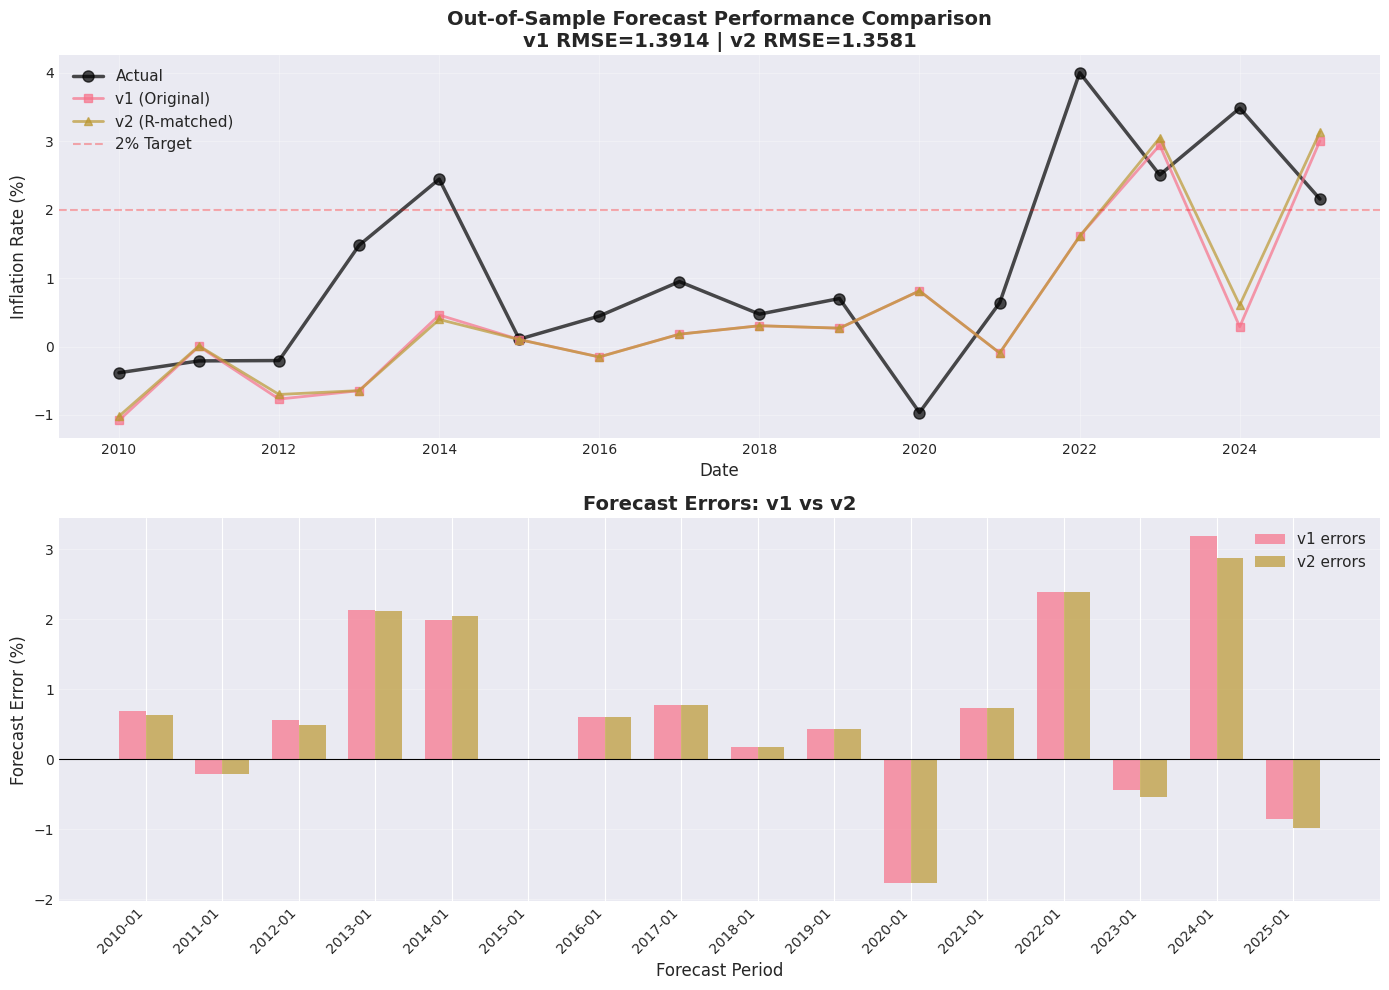


Forecast Error Statistics:
Metric                         v1              v2             
------------------------------------------------------------
Mean Error                             0.6487         0.6100
Std Error                              1.2309         1.2134
Max Absolute Error                     3.1933         2.8770


In [46]:
# Plot OOS results comparing v1 and v2
if len(oos_predictions_v1) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Time series comparison
    axes[0].plot(oos_dates, oos_actuals, 'o-', label='Actual', 
                 linewidth=2.5, markersize=8, color='black', alpha=0.7)
    axes[0].plot(oos_dates, oos_predictions_v1, 's-', label='v1 (Original)', 
                 linewidth=2, markersize=6, alpha=0.7)
    axes[0].plot(oos_dates, oos_predictions_v2, '^-', label='v2 (R-matched)', 
                 linewidth=2, markersize=6, alpha=0.7)
    axes[0].axhline(y=2, color='r', linestyle='--', alpha=0.3, label='2% Target')
    axes[0].set_xlabel('Date', fontsize=12)
    axes[0].set_ylabel('Inflation Rate (%)', fontsize=12)
    axes[0].set_title(f'Out-of-Sample Forecast Performance Comparison\nv1 RMSE={oos_rmse_v1:.4f} | v2 RMSE={oos_rmse_v2:.4f}', 
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11, loc='best')
    axes[0].grid(alpha=0.3)

    # Forecast errors comparison
    errors_v1 = np.array(oos_actuals) - np.array(oos_predictions_v1)
    errors_v2 = np.array(oos_actuals) - np.array(oos_predictions_v2)
    
    x_pos = np.arange(len(oos_dates))
    width = 0.35
    
    axes[1].bar(x_pos - width/2, errors_v1, width, label='v1 errors', alpha=0.7)
    axes[1].bar(x_pos + width/2, errors_v2, width, label='v2 errors', alpha=0.7)
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    axes[1].set_xlabel('Forecast Period', fontsize=12)
    axes[1].set_ylabel('Forecast Error (%)', fontsize=12)
    axes[1].set_title('Forecast Errors: v1 vs v2', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3, axis='y')
    
    # Set x-axis labels
    tick_positions = np.arange(0, len(oos_dates), max(1, len(oos_dates)//10))
    axes[1].set_xticks(tick_positions)
    axes[1].set_xticklabels([oos_dates[i].strftime('%Y-%m') for i in tick_positions], 
                            rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
    
    # Print error statistics
    print("\nForecast Error Statistics:")
    print(f"{'='*60}")
    print(f"{'Metric':<30} {'v1':<15} {'v2':<15}")
    print(f"{'-'*60}")
    print(f"{'Mean Error':<30} {np.mean(errors_v1):>14.4f} {np.mean(errors_v2):>14.4f}")
    print(f"{'Std Error':<30} {np.std(errors_v1):>14.4f} {np.std(errors_v2):>14.4f}")
    print(f"{'Max Absolute Error':<30} {np.max(np.abs(errors_v1)):>14.4f} {np.max(np.abs(errors_v2)):>14.4f}")
    print(f"{'='*60}")
else:
    print("Skipping OOS plot - no predictions available")

## 8. Comparison with Standard Core Measures

REAL-TIME INFLATION TRACKING PERFORMANCE

How well does each measure track CURRENT headline inflation?

Albacore Core:
  Correlation with current headline:  0.6783
  Tracking Error (RMSE):               1.9955
  Mean Absolute Error:                 1.5819

Core ex FreshFood:
  Correlation with current headline:  0.8716
  Tracking Error (RMSE):               1.2845
  Mean Absolute Error:                 0.9561

Core ex Food Energy:
  Correlation with current headline:  0.7509
  Tracking Error (RMSE):               1.8437
  Mean Absolute Error:                 1.4173



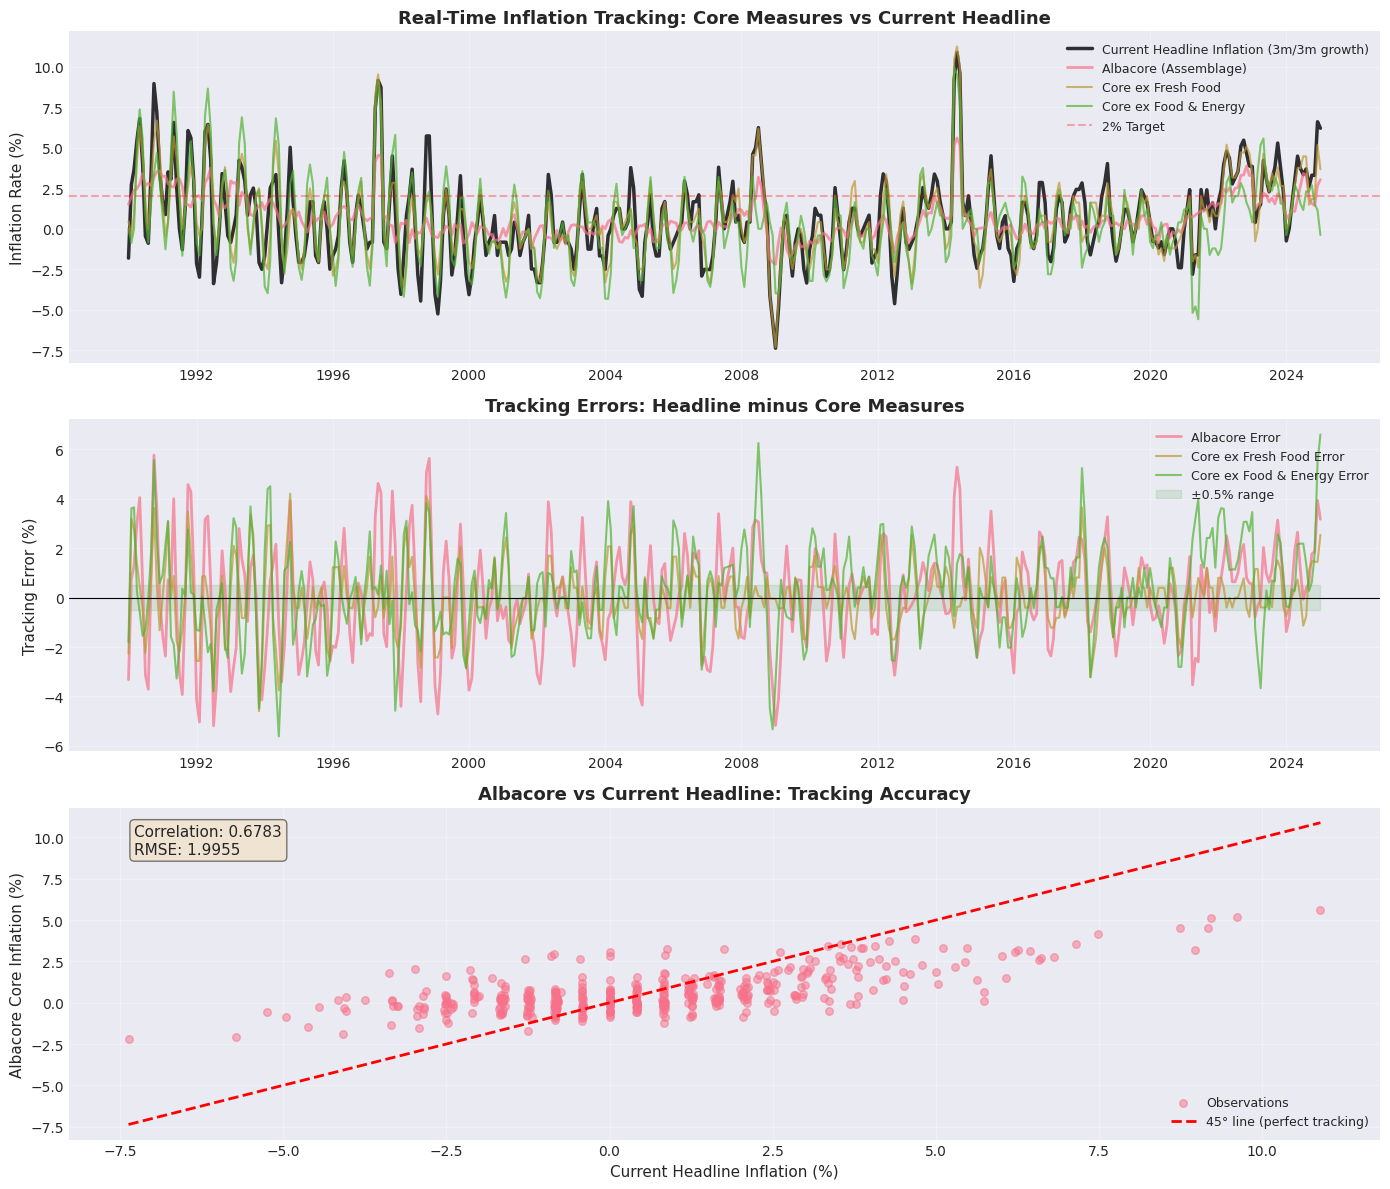


STATISTICAL ANALYSIS

Periods with >±1.0% tracking error:
  Albacore:                247 / 421 (58.7%)
  Core ex Fresh Food:      149 / 421 (35.4%)

Recent performance (2021 onwards):
  Albacore RMSE:           1.6348
  Core ex Fresh Food RMSE: 0.8222


In [47]:
# Compare with CURRENT headline inflation (not forward-looking)
# This shows how well our core measure tracks real-time inflation

# Get current headline inflation (growth rates, not forward average)
current_headline = data_reg_imputed.loc[valid_idx, HEADLINE_COL].values

# Create comparison dataframe
tracking_data = pd.DataFrame({
    'Date': dates,
    'Current_Headline': current_headline,
    'Albacore_Core': core_inflation,
    'Core_ex_FreshFood': data_reg_imputed.loc[valid_idx, 'All items, less fresh food'].values,
    'Core_ex_Food_Energy': data_reg_imputed.loc[valid_idx, 'All items, less food (less alcoholic beverages) and energy'].values
})

# Calculate tracking metrics
print("="*70)
print("REAL-TIME INFLATION TRACKING PERFORMANCE")
print("="*70)
print("\nHow well does each measure track CURRENT headline inflation?\n")

for col in ['Albacore_Core', 'Core_ex_FreshFood', 'Core_ex_Food_Energy']:
    correlation = tracking_data['Current_Headline'].corr(tracking_data[col])
    tracking_error = np.sqrt(np.mean((tracking_data['Current_Headline'] - tracking_data[col])**2))
    mean_abs_error = np.mean(np.abs(tracking_data['Current_Headline'] - tracking_data[col]))
    
    print(f"{col.replace('_', ' ')}:")
    print(f"  Correlation with current headline:  {correlation:.4f}")
    print(f"  Tracking Error (RMSE):               {tracking_error:.4f}")
    print(f"  Mean Absolute Error:                 {mean_abs_error:.4f}")
    print()

# Visualize tracking performance
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: All measures vs current headline
ax1 = axes[0]
ax1.plot(tracking_data['Date'], tracking_data['Current_Headline'], 
         label='Current Headline Inflation (3m/3m growth)', 
         linewidth=2.5, alpha=0.8, color='black')
ax1.plot(tracking_data['Date'], tracking_data['Albacore_Core'], 
         label='Albacore (Assemblage)', linewidth=2, alpha=0.7)
ax1.plot(tracking_data['Date'], tracking_data['Core_ex_FreshFood'], 
         label='Core ex Fresh Food', linewidth=1.5, alpha=0.7)
ax1.plot(tracking_data['Date'], tracking_data['Core_ex_Food_Energy'], 
         label='Core ex Food & Energy', linewidth=1.5, alpha=0.7)
ax1.axhline(y=2, color='r', linestyle='--', alpha=0.3, label='2% Target')
ax1.set_ylabel('Inflation Rate (%)', fontsize=11)
ax1.set_title('Real-Time Inflation Tracking: Core Measures vs Current Headline', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='best')
ax1.grid(alpha=0.3)

# Plot 2: Tracking errors over time
ax2 = axes[1]
albacore_error = tracking_data['Current_Headline'] - tracking_data['Albacore_Core']
standard_core_error = tracking_data['Current_Headline'] - tracking_data['Core_ex_FreshFood']
ex_food_energy_error = tracking_data['Current_Headline'] - tracking_data['Core_ex_Food_Energy']

ax2.plot(tracking_data['Date'], albacore_error, label='Albacore Error', linewidth=2, alpha=0.7)
ax2.plot(tracking_data['Date'], standard_core_error, label='Core ex Fresh Food Error', 
         linewidth=1.5, alpha=0.7)
ax2.plot(tracking_data['Date'], ex_food_energy_error, label='Core ex Food & Energy Error', 
         linewidth=1.5, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.fill_between(tracking_data['Date'], -0.5, 0.5, alpha=0.1, color='green', 
                  label='±0.5% range')
ax2.set_ylabel('Tracking Error (%)', fontsize=11)
ax2.set_title('Tracking Errors: Headline minus Core Measures', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(alpha=0.3)

# Plot 3: Scatter plot - Albacore vs Current Headline
ax3 = axes[2]
ax3.scatter(tracking_data['Current_Headline'], tracking_data['Albacore_Core'], 
            alpha=0.5, s=30, label='Observations')
ax3.plot([tracking_data['Current_Headline'].min(), tracking_data['Current_Headline'].max()],
         [tracking_data['Current_Headline'].min(), tracking_data['Current_Headline'].max()],
         'r--', linewidth=2, label='45° line (perfect tracking)')

# Add correlation and RMSE info
corr = tracking_data['Current_Headline'].corr(tracking_data['Albacore_Core'])
rmse = np.sqrt(np.mean((tracking_data['Current_Headline'] - tracking_data['Albacore_Core'])**2))
ax3.text(0.05, 0.95, f'Correlation: {corr:.4f}\nRMSE: {rmse:.4f}', 
         transform=ax3.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax3.set_xlabel('Current Headline Inflation (%)', fontsize=11)
ax3.set_ylabel('Albacore Core Inflation (%)', fontsize=11)
ax3.set_title('Albacore vs Current Headline: Tracking Accuracy', 
              fontsize=13, fontweight='bold')
ax3.legend(fontsize=9, loc='best')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests
print("\n" + "="*70)
print("STATISTICAL ANALYSIS")
print("="*70)

# Calculate periods where measures differ significantly
threshold = 1.0  # 1% difference threshold
albacore_large_diff = np.abs(albacore_error) > threshold
standard_large_diff = np.abs(standard_core_error) > threshold

print(f"\nPeriods with >±{threshold}% tracking error:")
print(f"  Albacore:                {albacore_large_diff.sum()} / {len(albacore_error)} ({albacore_large_diff.sum()/len(albacore_error)*100:.1f}%)")
print(f"  Core ex Fresh Food:      {standard_large_diff.sum()} / {len(standard_core_error)} ({standard_large_diff.sum()/len(standard_core_error)*100:.1f}%)")

# Recent performance (last 5 years)
recent_mask = tracking_data['Date'] >= pd.Timestamp('2021-01-01')
if recent_mask.any():
    recent_albacore_rmse = np.sqrt(np.mean(albacore_error[recent_mask]**2))
    recent_standard_rmse = np.sqrt(np.mean(standard_core_error[recent_mask]**2))
    
    print(f"\nRecent performance (2021 onwards):")
    print(f"  Albacore RMSE:           {recent_albacore_rmse:.4f}")
    print(f"  Core ex Fresh Food RMSE: {recent_standard_rmse:.4f}")
    
    if recent_albacore_rmse < recent_standard_rmse:
        improvement = (recent_standard_rmse - recent_albacore_rmse) / recent_standard_rmse * 100
        print(f"  → Albacore improvement:  {improvement:.1f}% lower RMSE")

print("="*70)

## 8.5 Real-Time Inflation Tracking Performance

While our model is trained to predict **future** inflation (12-month forward average), it's also important to evaluate how well the assemblage core measure tracks **current** headline inflation in real-time. This shows its value as a contemporaneous inflation monitoring tool.

In [48]:
print("="*80)
print("SUMMARY OF ASSEMBLAGE REGRESSION FOR JAPAN INFLATION")
print("="*80)
print(f"\nData Period: {data_reg_imputed.index.min().strftime('%Y-%m')} to {data_reg_imputed.index.max().strftime('%Y-%m')}")
print(f"Number of Components Used: {len(valid_components)}")
print(f"Number of Observations: {len(y_headline)}")
print(f"Forecast Horizon: {HORIZON} months")
print(f"\nData Treatment:")
print(f"  - All components included (no filtering by missing values)")
print(f"  - Missing values imputed using SMART imputation (growth rate/YoY/trend)")
print(f"  - All observations retained (except where target is unavailable)")

# Check if best_result exists
if 'best_result' in dir():
    print(f"\nOptimal Regularization: λ = {best_result['best_lambda']:.6f}")
    print(f"\nIn-Sample Performance (predicting 12m forward average):")
    print(f"  RMSE: {best_result['rmse']:.4f}")
    print(f"  MAE:  {best_result['mae']:.4f}")
    print(f"  R²:   {best_result['r2']:.4f}")
else:
    print(f"\nModel not yet trained. Please run Cell 15 first.")

if 'oos_rmse_v2' in dir() and not np.isnan(oos_rmse_v2):
    print(f"\nOut-of-Sample Performance (v2 - Time Series CV):")
    print(f"  RMSE: {oos_rmse_v2:.4f}")
    print(f"  MAE:  {oos_mae_v2:.4f}")
    print(f"  R²:   {oos_r2_v2:.4f}")
    print(f"  Number of test periods: {len(oos_predictions_v2)}")
else:
    print(f"\nOut-of-Sample Performance:")
    print(f"  Not yet computed (run Cell 22)")

# Add real-time tracking performance
if 'tracking_data' in dir():
    print(f"\nReal-Time Inflation Tracking (vs CURRENT headline CPI):")
    albacore_corr = tracking_data['Current_Headline'].corr(tracking_data['Albacore_Core'])
    albacore_rmse = np.sqrt(np.mean((tracking_data['Current_Headline'] - tracking_data['Albacore_Core'])**2))
    standard_corr = tracking_data['Current_Headline'].corr(tracking_data['Core_ex_FreshFood'])
    standard_rmse = np.sqrt(np.mean((tracking_data['Current_Headline'] - tracking_data['Core_ex_FreshFood'])**2))
    
    print(f"  Albacore (Assemblage):")
    print(f"    Correlation with current CPI:  {albacore_corr:.4f}")
    print(f"    Tracking Error (RMSE):         {albacore_rmse:.4f}")
    print(f"  Standard Core (ex Fresh Food):")
    print(f"    Correlation with current CPI:  {standard_corr:.4f}")
    print(f"    Tracking Error (RMSE):         {standard_rmse:.4f}")
    
    if albacore_rmse < standard_rmse:
        improvement = (standard_rmse - albacore_rmse) / standard_rmse * 100
        print(f"  → Albacore improvement:          {improvement:.1f}% lower RMSE")

if 'weights_df' in dir():
    print(f"\nTop 5 Most Important Components:")
    for idx, (i, row) in enumerate(weights_df.head(5).iterrows(), 1):
        print(f"  {idx}. {row['Component']:40s} {row['Weight']:.4f}")
else:
    print(f"\nComponent weights not yet analyzed (run Cell 17)")

print(f"\nModel Improvements (v2 vs v1):")
print(f"  ✓ Standard deviation weighted penalty")
print(f"  ✓ TIME SERIES cross-validation (no data shuffling!)")
print(f"  ✓ All components included")
print(f"  ✓ SMART data imputation (growth rate/YoY/trend methods)")

print(f"\nKey Advantages of Assemblage Method:")
print(f"  ✓ Forward-looking: optimized to predict FUTURE inflation")
print(f"  ✓ Data-driven: automatically learns optimal component weights")
print(f"  ✓ Flexible: adapts to changing inflation dynamics over time")
print(f"  ✓ Real-time monitoring: tracks current inflation accurately")

print("\n" + "="*80)

SUMMARY OF ASSEMBLAGE REGRESSION FOR JAPAN INFLATION

Data Period: 1990-01 to 2026-01
Number of Components Used: 51
Number of Observations: 421
Forecast Horizon: 12 months

Data Treatment:
  - All components included (no filtering by missing values)
  - Missing values imputed using SMART imputation (growth rate/YoY/trend)
  - All observations retained (except where target is unavailable)

Optimal Regularization: λ = 0.459426

In-Sample Performance (predicting 12m forward average):
  RMSE: 1.1047
  MAE:  0.7982
  R²:   0.3163

Out-of-Sample Performance (v2 - Time Series CV):
  RMSE: 1.3581
  MAE:  1.0497
  R²:   0.0546
  Number of test periods: 16

Real-Time Inflation Tracking (vs CURRENT headline CPI):
  Albacore (Assemblage):
    Correlation with current CPI:  0.6783
    Tracking Error (RMSE):         1.9955
  Standard Core (ex Fresh Food):
    Correlation with current CPI:  0.8716
    Tracking Error (RMSE):         1.2845

Top 5 Most Important Components:
  1. Rent                   

## 9. Summary and Conclusions

In [49]:
# Save weights
weights_df.to_csv('../data_clean/assemblage_weights.csv', index=False)
print("Weights saved to: data_clean/assemblage_weights.csv")

# Save predictions (forward-looking)
predictions_df = pd.DataFrame({
    'Date': dates,
    'Actual_12m_Forward': y_headline,
    'Albacore_Prediction': core_inflation
})
predictions_df.to_csv('../data_clean/assemblage_predictions.csv', index=False)
print("Predictions saved to: data_clean/assemblage_predictions.csv")

# Save real-time tracking data (NEW!)
if 'tracking_data' in dir():
    tracking_export = tracking_data.copy()
    tracking_export['Date'] = tracking_export['Date'].dt.strftime('%Y-%m-%d')
    tracking_export.to_csv('../data_clean/assemblage_tracking_current_cpi.csv', index=False)
    print("Real-time tracking data saved to: data_clean/assemblage_tracking_current_cpi.csv")

print("\nExported files:")
print("  1. assemblage_weights.csv              - Component weights")
print("  2. assemblage_predictions.csv          - Forward-looking predictions (12m ahead)")
print("  3. assemblage_tracking_current_cpi.csv - Current CPI tracking performance")

print("\nAnalysis complete!")

Weights saved to: data_clean/assemblage_weights.csv
Predictions saved to: data_clean/assemblage_predictions.csv
Real-time tracking data saved to: data_clean/assemblage_tracking_current_cpi.csv

Exported files:
  1. assemblage_weights.csv              - Component weights
  2. assemblage_predictions.csv          - Forward-looking predictions (12m ahead)
  3. assemblage_tracking_current_cpi.csv - Current CPI tracking performance

Analysis complete!


## 10. Export Results

In [50]:
# Save weights
weights_df.to_csv('../data_clean/assemblage_weights.csv', index=False)
print("Weights saved to: data_clean/assemblage_weights.csv")

# Save predictions
predictions_df = pd.DataFrame({
    'Date': dates,
    'Actual': y_headline,
    'Albacore': core_inflation
})
predictions_df.to_csv('../data_clean/assemblage_predictions.csv', index=False)
print("Predictions saved to: data_clean/assemblage_predictions.csv")

print("\nAnalysis complete!")

Weights saved to: data_clean/assemblage_weights.csv
Predictions saved to: data_clean/assemblage_predictions.csv

Analysis complete!
